In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

import geopandas as gpd
import ee
import numpy as np
from matplotlib import pyplot as plt
import shapely
import requests
import io
import rasterio
import json

PROJECT_ID = "hedgementation"
ee.Initialize(project=PROJECT_ID)

In [7]:
IMG_ARGUMENTS = {
    "width": 7,
    "initial_scale": 0.5,
    "final_scale": 0.5,
    "reduce_resolution": False,
    "crs": "EPSG:3857",
    "crsTransform": [0, 0, 0, 0, 0, 0]
}

In [8]:
gdf = gpd.read_file("gpkgs/hedgementation_dataset_1.2.gpkg").to_crs("EPSG:3857")
hedgerows = shapely.wkt.loads(gdf.iloc[1644]["hedgerows"])
bounds =  gdf.iloc[1644].geometry

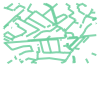

In [22]:
hedgerows

In [9]:
def rasterize_hedgerows(multiLineString, 
                        crs, 
                        crsTransform, 
                        bounding_rect,
                        width=3,
                        initial_scale=2,
                        final_scale=10,
                        reduce_resolution=True):
    
    
    if not isinstance(multiLineString, ee.Geometry):
        multiLineString = ee.Geometry(json.loads(shapely.to_geojson(multiLineString)))
    
    if not isinstance(bounding_rect, ee.Geometry):
        bounding_rect = ee.Geometry(json.loads(shapely.to_geojson(bounding_rect)))
    crsTransform = ee.List(crsTransform)
    crs = ee.Projection(crs)


    #width_in_pixels = width / initial_scale
    buffered_linestring = multiLineString.buffer(width / 2)
    crs_transform_initial = [initial_scale, 0, crsTransform.get(2), 0, -initial_scale, crsTransform.get(5)]
    canvas = ee.Image.constant(0).reproject(
        crs=crs,
        crsTransform=crs_transform_initial
    ).clip(bounding_rect)

    raster = canvas.paint(buffered_linestring, color=1).clip(bounding_rect)

    crs_transform_final = [final_scale, 0, crsTransform.get(2), 0, -final_scale, crsTransform.get(5)]

    if reduce_resolution:
        image_fraction = raster.reduceResolution(
            reducer=ee.Reducer.mean(),
            maxPixels=(final_scale / initial_scale) ** 2,
        ).reproject(crs=crs, crsTransform=crs_transform_final)
        return image_fraction
    else:
        return raster

Download URL: https://earthengine.googleapis.com/v1/projects/hedgementation/thumbnails/5a62e405a23c1b1cec9e82c9d58d84d1-38d5ef13ca86cfb69c5728c2751e3785:getPixels
Image shape: (2561, 2561)
Image values: Min=0, Max=0


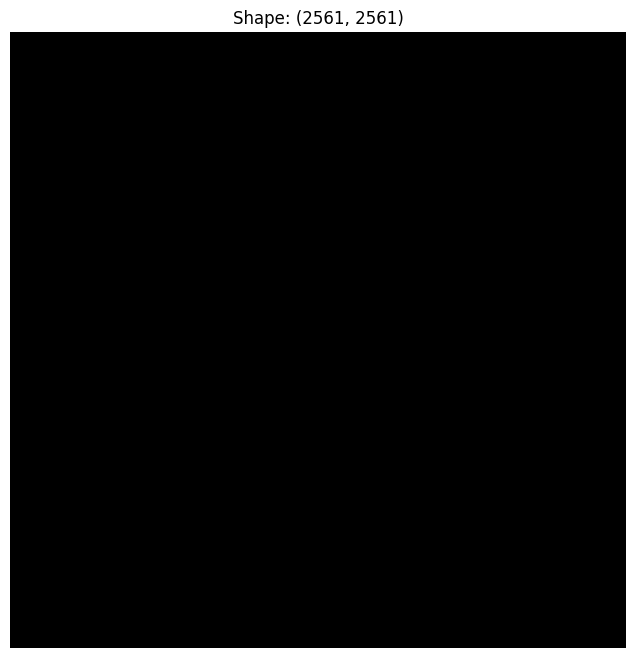

'https://earthengine.googleapis.com/v1/projects/hedgementation/thumbnails/5a62e405a23c1b1cec9e82c9d58d84d1-38d5ef13ca86cfb69c5728c2751e3785:getPixels'

In [21]:
import ee
import json
import shapely
import shapely.ops
import pyproj
import requests
import io
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. Helper to safely reproject Shapely geometry to Lat/Lon (WGS84)
def to_wgs84(geometry, source_crs='EPSG:3857'):
    """Converts a shapely geometry from source_crs to EPSG:4326 (Lat/Lon)"""
    if not hasattr(geometry, 'geom_type'): # Handle if it's already a dict or str
        return geometry
        
    source = pyproj.CRS(source_crs)
    target = pyproj.CRS('EPSG:4326')
    project = pyproj.Transformer.from_crs(source, target, always_xy=True).transform
    return shapely.ops.transform(project, geometry)

def rasterize_hedgerows_strict(multiLineString, bounding_rect, width=3):
    # Ensure inputs are ee.Geometry
    if not isinstance(multiLineString, ee.Geometry):
        multiLineString = ee.Geometry(json.loads(shapely.to_geojson(multiLineString)))
    
    if not isinstance(bounding_rect, ee.Geometry):
        bounding_rect = ee.Geometry(json.loads(shapely.to_geojson(bounding_rect)))

    # --- CRITICAL FIX 1: BUFFER IN METERS ---
    # We pass 'EPSG:3857' to .buffer(). 
    # This tells GEE: "The width=3 is in METERS, not degrees."
    buffered_linestring = multiLineString.buffer(width / 2, proj='EPSG:3857')
    
    features = ee.FeatureCollection([ee.Feature(buffered_linestring)])
    
    # Paint: 0 background, 1 foreground. Clip to the bounds.
    raster = ee.Image(0).byte().paint(features, 1).clip(bounding_rect)
    
    return raster

def download_single_image_correct(hedgerows, bounds, width=7, scale=0.5, show=True, source_crs='EPSG:3857'):

    # 1. Pre-process: Convert Shapely inputs to WGS84 so GEE knows where they are
    hedgerows_wgs84 = to_wgs84(hedgerows, source_crs)
    bounds_wgs84 = to_wgs84(bounds, source_crs)
    
    # 2. Rasterize (using the fix above)
    img = rasterize_hedgerows_strict(hedgerows_wgs84, bounds_wgs84, width=width)

    # 3. Get the bounds in WGS84 for the region parameter
    # (We need the region in Lat/Lon for the API call)
    region_coords = ee.Geometry(json.loads(shapely.to_geojson(bounds_wgs84))).bounds().getInfo()['coordinates']

    # --- CRITICAL FIX 2: DOWNLOAD IN METERS ---
    # We explicitly request 'crs': 'EPSG:3857'.
    # This forces the output pixels to be square meters, matching your original Shapely box.
    url = img.getDownloadURL({
        'scale': scale,
        'region': region_coords,
        'format': 'GEO_TIFF',
        'crs': 'EPSG:3857' 
    })
    
    print(f'Download URL: {url}')

    if show:
        response = requests.get(url)
        try:
            tiff_bytes = io.BytesIO(response.content)
            with rasterio.open(tiff_bytes) as infile:
                img_array = np.array(infile.read(1))
                print(f"Image shape: {img_array.shape}")
                print(f"Image values: Min={img_array.min()}, Max={img_array.max()}")
                
                if img_array.max() == 0:
                    print("WARNING: Image is all black (0). Check if hedgerows actually overlap the bounds.")
                
                plt.figure(figsize=(8, 8))
                # Use vmin/vmax to force contrast even if image is faint
                plt.imshow(img_array, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
                plt.axis('off')
                plt.title(f"Shape: {img_array.shape}")
                plt.show()
            
        except Exception as img_error:
            print(f"Error opening image: {img_error}")
            print(response.content[:100]) # Print error from GEE if not a TIFF
      
    return url

# Run it
# Ensure 'hedgerows' and 'bounds' are your original Shapely objects in Meters (e.g., UTM or Mercator)
# If your shapely objects are ALREADY in Lat/Lon, change source_crs to 'EPSG:4326'
download_single_image_correct(hedgerows, bounds, width=7, scale=0.5, show=True, source_crs='EPSG:3857')